# HPD 1 — Pipeline de embeddings y búsqueda semántica

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/evaluables/hpd1-embeddings.ipynb)

> **Duración:** 4h
>
> **Competencias:** [CE-1](../index.qmd#competencias-específicas)

> **Objetivos**
>
> - Construir un pipeline de embeddings end-to-end
> - Usar LangChain para carga de PDFs y chunking con solapamiento
> - Generar embeddings con un modelo open-source
> - Indexar en Chroma y ejecutar búsqueda semántica
> - Evaluar calidad con recall@k
> - Validar el modelo con benchmarks estándar (MTEB)
>
> ## Materiales
>
> - Librerías: `langchain`, `langchain-text-splitters`,
>   `sentence-transformers`, `chromadb`, `pypdf`, `fpdf2`, `arxiv`,
>   `mteb`
> - Modelo: `intfloat/e5-small-v2`
> - Corpus: abstracts reales de ArXiv convertidos a PDF con `fpdf2`
> - Corpus real: 6 papers de ArXiv
>
> ## Pipeline
>
> 1.  **Parte 1 — Aproximación conceptual:** abstracts reales, pipeline
>     completo en pequeño
> 2.  **Parte 2 — Escenario realista:** corpus real de ArXiv, indexación
>     a escala, evaluación MTEB

> **¿Por qué necesitas esto?**
>
> Imagina que trabajas en un despacho de abogados buscando cláusulas de
> confidencialidad en 500 contratos. O en una multinacional filtrando
> currículums por habilidades, no por palabras clave exactas. O en un
> hospital recuperando historiales clínicos con síntomas parecidos. Los
> tres problemas se resuelven con **la misma arquitectura**: convertir
> documentos en vectores y buscar por similitud semántica.
>
> Al final de este taller sabrás construir ese pipeline de principio a
> fin. Y lo mejor: cambiar de dominio (legal, médico, financiero) solo
> requiere cambiar los documentos de entrada — el código es el mismo.

In [1]:
!pip install -q chromadb sentence-transformers fpdf2 arxiv mteb matplotlib scikit-learn pandas langchain langchain-community langchain-text-splitters pypdf

In [2]:
import os
import tempfile
import shutil
import requests
import arxiv
import matplotlib.pyplot as plt
import pandas as pd
from fpdf import FPDF
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import chromadb
import numpy as np

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

# ------------------------------------------------------------------ Parámetros compartidos
CHUNK_SIZE = 300      # caracteres por chunk  (antes usábamos palabras; ahora LangChain usa caracteres)
CHUNK_OVERLAP = 50    # caracteres de solapamiento
MODEL_NAME = "intfloat/e5-small-v2"

# ------------------------------------------------------------------ Directorios temporales
BASE_DIR = tempfile.mkdtemp()
CORPUS_SINTETICO = os.path.join(BASE_DIR, "corpus_sintetico")
CORPUS_REAL = os.path.join(BASE_DIR, "corpus_real")
os.makedirs(CORPUS_SINTETICO)
os.makedirs(CORPUS_REAL)
print(f"Directorio temporal: {BASE_DIR}")

# ------------------------------------------------------------------ Modelo de embeddings
model = SentenceTransformer(MODEL_NAME)
print(f"Modelo cargado: {MODEL_NAME}")
print(f"  Dimensión de embeddings: {model.get_embedding_dimension()}")

# ------------------------------------------------------------------ Chroma (cliente compartido)
client = chromadb.EphemeralClient()

------------------------------------------------------------------------

# Parte 1 — Aproximación conceptual

En esta primera parte construimos el pipeline completo sobre un corpus
de 3 PDFs generados con los abstracts reales de papers de ArXiv:
*Attention Is All You Need*, *Sentence-BERT* y *RAG*. Son los mismos
papers que indexaremos completos en la Parte 2.

## 1.1 Corpus: abstracts reales de ArXiv

Usamos `arxiv` para descargar los abstracts de 3 papers clave del
módulo. Con `fpdf2` los convertimos en PDFs para que el pipeline de
ingesta (carga → chunking → indexación) sea idéntico al que usarás con
documentos reales.

In [3]:
class PDF(FPDF):
    pass

def crear_pdf(nombre: str, titulo: str, contenido: str) -> None:
    pdf = PDF()
    pdf.add_page()
    pdf.set_font("Helvetica", "B", 16)
    pdf.cell(0, 10, titulo, new_x="LMARGIN", new_y="NEXT")
    pdf.ln(5)
    pdf.set_font("Helvetica", "", 11)
    pdf.multi_cell(0, 6, contenido)
    pdf.output(os.path.join(CORPUS_SINTETICO, nombre))
    print(f"  ✅ {nombre}")

# Descargar abstracts de ArXiv
arxiv_client = arxiv.Client()
ABSTRACT_IDS = ["1706.03762", "1908.10084", "2005.11401"]
search = arxiv.Search(id_list=ABSTRACT_IDS)

abstracts = {}
for paper in arxiv_client.results(search):
    aid = paper.get_short_id().split("v")[0]
    abstracts[aid] = (paper.title, paper.summary.replace("\n", " ").strip())
    print(f"  ✅ {aid}: {paper.title[:70]}...")

# Construir el corpus con los abstracts
corpus = {
    f"{aid}.pdf": (title, summary)
    for aid, (title, summary) in abstracts.items()
}

print("Generando PDFs con abstracts reales...")
for nombre, (titulo, contenido) in corpus.items():
    crear_pdf(nombre, titulo, contenido)
print(f"Corpus generado: {len(corpus)} PDFs en {CORPUS_SINTETICO}")

## 1.2 Carga de PDFs con LangChain

`PyPDFLoader` carga documentos PDF y devuelve una lista de objetos
`Document` de LangChain. Cada `Document` tiene `.page_content` (texto) y
`.metadata` (fuente, nº de página, etc.).

In [4]:
def cargar_pdfs(dir_path: str) -> list:
    """
    Carga todos los PDFs de un directorio usando PyPDFLoader de LangChain.

    Args:
        dir_path: Ruta al directorio con archivos .pdf

    Returns:
        list[Document]: Documentos LangChain con page_content y metadata.
    """
    documentos = []

    for filename in sorted(os.listdir(dir_path)):
        if not filename.endswith(".pdf"):
            continue

        ruta = os.path.join(dir_path, filename)

        # TODO: Crear un PyPDFLoader con la ruta del archivo
        # TODO: Llamar a loader.load() para obtener los Document
        # TODO: Extender la lista documentos con los documentos cargados

    return documentos


docs = cargar_pdfs(CORPUS_SINTETICO)
print(f"Documentos cargados: {len(docs)}")
for doc in docs:
    print(f"  {doc.metadata.get('source', '?')}: {len(doc.page_content)} caracteres")

> **¿Qué es un embedding?**
>
> Un embedding convierte un texto en una lista de números (384 en
> nuestro caso). La clave está en que **textos con significado parecido
> producen números parecidos**, aunque usen palabras distintas.
>
> Imagina un mapa donde cada documento es un punto. Los documentos que
> hablan de lo mismo quedan cerca. Cuando haces una pregunta, el modelo
> la sitúa en ese mismo mapa y busca los vecinos más próximos.
>
> El modelo que usamos, `e5-small-v2`, tiene solo 33 millones de
> parámetros: ligero para ejecutar en local pero con muy buena calidad
> para búsqueda semántica.

## 1.3 Chunking con RecursiveCharacterTextSplitter

En vez de partir a mano por palabras, usamos
`RecursiveCharacterTextSplitter` de LangChain: intenta cortar por
párrafos (`\n\n`), luego por saltos de línea, luego por frases (`.`) y
por último por espacios. Así los chunks mantienen sentido y no se cortan
a mitad de una frase.

In [5]:
# TODO: Crear un RecursiveCharacterTextSplitter configurando:
#   chunk_size       — caracteres por chunk
#   chunk_overlap    — caracteres de solapamiento
#   separators       — ["\n\n", "\n", ". ", " ", ""] (orden de preferencia)

splitter = None  # ← completar

# TODO: Llamar a splitter.split_documents(docs) para dividir los documentos
chunks = None  # ← completar

print(f"Chunks generados: {len(chunks)}")
for i, chunk in enumerate(chunks):
    fuente = os.path.basename(chunk.metadata["source"])
    print(f"  [{i}] {fuente}: {len(chunk.page_content)} caracteres")

## 1.4 Embeddings e indexación en Chroma

Cada chunk se codifica con `model.encode()` y se inserta en la colección
vectorial.

In [6]:
collection = client.get_or_create_collection(
    name="hpd1_sintetico",
    metadata={"hnsw:space": "cosine"}
)

print("Generando embeddings e indexando...")

for chunk_idx, chunk in enumerate(chunks):
    embedding = model.encode(chunk.page_content).tolist()

    fuente = os.path.basename(chunk.metadata["source"])
    chunk_id = f"{fuente.replace('.pdf', '')}_chunk_{chunk_idx}"

    # TODO: collection.add() con:
    #   ids          — [chunk_id]
    #   embeddings   — [embedding]
    #   documents    — [chunk.page_content]
    #   metadatas    — [{"fuente": fuente, "chunk_index": chunk_idx}]

print(f"Indexación completada: {collection.count()} vectores en Chroma")

> **¿Chroma, FAISS o Qdrant? ¿Cuál elijo?**
>
> |  | Chroma | FAISS | Qdrant |
> |------------------|------------------|------------------|------------------|
> | **Instalación** | `pip install chromadb` | `pip install faiss-cpu` | Docker o cloud |
> | **Escala máxima** | ~500k vectores | Miles de millones | Miles de millones |
> | **Privacidad** | Total (local, sin servidor) | Total (librería embebible) | Depende del despliegue |
> | **Ideal para…** | Prototipos, HPDs, proyectos pequeños | Producción on-premise, búsqueda a gran escala | Cloud multi-tenant, API REST nativa |
> | **Lo usamos en…** | HPD 1, HPD 4 (RAG) | — | — |
>
> **Regla práctica:** empieza con Chroma (es lo que usamos aquí). Si tu
> proyecto crece a \>100k documentos o necesitas servir consultas por
> API, migra a Qdrant. Si necesitas máxima velocidad en local con
> millones de vectores, FAISS.

## 1.5 Búsqueda semántica

La consulta se codifica y se recuperan los `k` chunks más similares por
distancia coseno.

In [7]:
def buscar(collection, query: str, k: int = 5) -> dict:
    """
    Realiza una búsqueda semántica en una colección vectorial.

    Args:
        collection: Colección de Chroma donde buscar.
        query: Consulta en lenguaje natural.
        k: Número de resultados a recuperar.

    Returns:
        dict: Resultado de Chroma con ids, distances, documents y metadatas.
    """
    query_embedding = model.encode(query).tolist()

    # TODO: Llamar a collection.query() con:
    #   query_embeddings — [query_embedding]
    #   n_results        — k

    return resultados


resultados = buscar(collection, "¿Cómo funciona la atención en los Transformers?", k=3)
print("\nResultados para: '¿Cómo funciona la atención en los Transformers?'")
for i, (chunk_id, distancia, texto) in enumerate(zip(
    resultados["ids"][0],
    resultados["distances"][0],
    resultados["documents"][0],
)):
    print(f"\n  {i + 1}. {chunk_id}  (distancia: {distancia:.4f})")
    print(f"     {texto[:150]}...")

> **Similitud coseno vs. distancia coseno**
>
> Chroma devuelve **distancias**, no similitudes. La relación es:
>
> $$\text{distancia} = 1 - \text{similitud}$$
>
> | Métrica | Rango | Interpretación |
> |------------------------|------------------------|------------------------|
> | **Similitud coseno** | $[-1, 1]$ | $1$ = idénticos, $0$ = ortogonales, $-1$ = opuestos |
> | **Distancia coseno** | $[0, 2]$ | $0$ = idénticos, $1$ = ortogonales, $2$ = opuestos |
>
> Con embeddings normalizados (lo habitual), la similitud coseno
> equivale al producto escalar y oscila en $[0, 1]$. La distancia, por
> tanto, está en $[0, 1]$. **Cuanto menor es la distancia, más relevante
> es el chunk.**

## 1.6 Más allá del texto: embeddings de datos tabulares

Hasta ahora hemos hecho embeddings de PDFs. Pero, ¿y si tus datos están
en un Excel? La buena noticia: **el pipeline no cambia**. Solo cambia
cómo conviertes cada fila en texto.

In [8]:
# Dataset tabular de ejemplo: empleados
df_empleados = pd.DataFrame({
    "nombre":       ["Ana García", "Carlos Ruiz", "Beatriz López", "David Martín"],
    "departamento": ["I+D",        "Ventas",       "I+D",           "Operaciones"],
    "salario":      [55000,        47000,          48000,           51000],
    "antiguedad":   [7,            4,              3,               5],
})

# Convertir cada fila en un "documento" textual
df_empleados["documento"] = df_empleados.apply(
    lambda r: f"Empleado {r['nombre']}. Departamento {r['departamento']}. "
              f"Salario {r['salario']} euros. Antigüedad {r['antiguedad']} años.",
    axis=1
)

print("Filas convertidas a texto:")
for doc in df_empleados["documento"]:
    print(f"  → {doc}")

# Mismo modelo, mismo encode(), mismo pipeline
embeddings_tab = model.encode(df_empleados["documento"].tolist())
print(f"\nEmbeddings tabulares: {embeddings_tab.shape}")

In [9]:
# Indexar en Chroma — idéntico a como hiciste con PDFs
collection_tab = client.get_or_create_collection(
    name="hpd1_tabular",
    metadata={"hnsw:space": "cosine"}
)

for i, (_, row) in enumerate(df_empleados.iterrows()):
    collection_tab.add(
        ids=[f"emp_{i}"],
        embeddings=[embeddings_tab[i].tolist()],
        documents=[row["documento"]],
        metadatas=[{"nombre": row["nombre"], "departamento": row["departamento"]}]
    )

print(f"Indexación completada: {collection_tab.count()} vectores en Chroma")

# Buscar: "empleados senior de I+D"
res = collection_tab.query(
    query_embeddings=[model.encode("empleados senior de I+D").tolist()],
    n_results=2
)
print("\nBúsqueda: 'empleados senior de I+D'")
for doc, dist in zip(res["documents"][0], res["distances"][0]):
    print(f"  {doc[:80]}... (dist: {dist:.4f})")

> **¿Qué modelo de embeddings uso según mi tipo de dato?**
>
> | Tipo de dato | Modelo recomendado | ¿Requiere entrenamiento? |
> |------------------------|------------------------|------------------------|
> | **Texto** (PDFs, webs, emails) | `e5-small-v2`, `text-embedding-3-small` | No, vienen pre-entrenados |
> | **Tabular (rápido)** | Texto concatenado + `e5-small-v2` | No, usas el mismo modelo |
> | **Tabular (riguroso)** | TabNet, SCARF | **Sí**, requieren GPU y target supervisado |
> | **Código fuente** | CodeBERT, UnixCoder | No, vienen pre-entrenados |
> | **Imágenes + texto** | CLIP | No, pre-entrenado multimodal |
>
> La clave: el pipeline (`encode → index → search`) es el mismo. Solo
> cambia el modelo de embeddings. Si cambias de dominio, cambias los
> documentos de entrada, no el código.

> **Limitación honesta del texto concatenado**
>
> Este enfoque no sabe que 55000 está numéricamente más cerca de 52000
> que de 12000. Para eso existen modelos especializados como **TabNet**
> (atención sobre columnas tabulares) y **SCARF** (contrastive learning
> tabular), que se mencionan en la teoría del Bloque 1. Ambos requieren
> entrenamiento supervisado con GPU.
>
> Para el 80% de los casos reales de búsqueda semántica sobre datos
> corporativos (buscar empleados por perfil, filtrar productos por
> características, recuperar registros por descripción), el texto
> concatenado es suficiente.

## 1.7 Evaluación con recall@k

> **¿Qué mide recall@k?**
>
> De todos los chunks que **deberían** aparecer para una consulta (los
> anotamos a mano como ground truth), ¿cuántos recupera el sistema entre
> los primeros *k* resultados?
>
> | Ejemplo con k=1 | Ejemplo con k=5 |
> |----|----|
> | Solo miramos el primer resultado | Miramos los 5 primeros |
> | Si acierta → 1.0 | Si los 2 relevantes salen entre los 5 → 1.0 |
> | Muy exigente | Más realista para búsquedas exploratorias |
>
> Definimos manualmente qué chunks esperamos para cada consulta. Esa
> lista es el *ground truth*: el criterio humano contra el que medimos
> al sistema.

In [10]:
def recall_at_k(retrieved_ids: list, relevant_ids: list, k: int) -> float:
    """
    Calcula recall@k: proporción de documentos relevantes recuperados en el top-k.

    Args:
        retrieved_ids: IDs recuperados por el sistema (ordenados por relevancia).
        relevant_ids: IDs relevantes esperados (ground truth).
        k: Ventana de resultados a considerar.

    Returns:
        float: recall@k ∈ [0, 1].
    """
    if len(relevant_ids) == 0:
        return 0.0

    # TODO: Tomar los primeros k IDs recuperados
    # TODO: Contar cuántos IDs relevantes aparecen en el top-k
    # TODO: Dividir entre el total de IDs relevantes

    return ...  # ← completar


QUERIES_PRUEBA = {
    "How does multi-head attention work?": [
        "1706.03762_chunk_0", "1706.03762_chunk_1",
    ],
    "What are sentence embeddings?": [
        "1908.10084_chunk_0", "1908.10084_chunk_1",
    ],
    "How does RAG combine retrieval with generation?": [
        "2005.11401_chunk_0", "2005.11401_chunk_1",
    ],
    "What is the Transformer architecture?": [
        "1706.03762_chunk_0", "1706.03762_chunk_1",
    ],
    "What tasks does RAG improve?": [
        "2005.11401_chunk_2", "2005.11401_chunk_3",
    ],
}

print("Evaluación recall@k — corpus con abstracts reales")
print("=" * 60)

for k in [1, 3, 5]:
    recalls = []
    for query, relevantes in QUERIES_PRUEBA.items():
        res = buscar(collection, query, k=k)
        retrieved = res["ids"][0]
        r = recall_at_k(retrieved, relevantes, k)
        recalls.append(r)

    media = np.mean(recalls)
    print(f"\n  k = {k}")
    print(f"    Recalls individuales: {[f'{r:.2f}' for r in recalls]}")
    print(f"    recall@{k} medio: {media:.3f}")

## Limpieza parte 1

In [11]:
client.delete_collection("hpd1_sintetico")
client.delete_collection("hpd1_tabular")
shutil.rmtree(CORPUS_SINTETICO)
print("✅ Parte 1 limpiada (colecciones + corpus temporal eliminados)")

------------------------------------------------------------------------

# Parte 2 — Escenario realista

En esta segunda parte repetimos el pipeline sobre un corpus real: **6
papers descargados de ArXiv**. Además añadimos una **evaluación
profesional con MTEB** para validar la calidad del modelo de embeddings.

## 2.1 Corpus real — Descarga de ArXiv

In [12]:
PAPERS = {
    "1706.03762": "Attention Is All You Need (Vaswani et al., 2017)",
    "1810.04805": "BERT: Pre-training of Deep Bidirectional Transformers (Devlin et al., 2019)",
    "1908.10084": "Sentence-BERT (Reimers & Gurevych, 2019)",
    "2005.11401": "RAG: Retrieval-Augmented Generation (Lewis et al., 2020)",
    "2106.09685": "LoRA: Low-Rank Adaptation (Hu et al., 2022)",
    "2309.15217": "RAGAS: Automated Evaluation (Es et al., 2023)",
}

def descargar_paper(arxiv_id: str, dir_path: str) -> str:
    """Descarga un paper de ArXiv por ID, con caché local."""
    ruta_pdf = os.path.join(dir_path, f"{arxiv_id}.pdf")
    if os.path.exists(ruta_pdf):
        return ruta_pdf

    client_arxiv = arxiv.Client()
    search = arxiv.Search(id_list=[arxiv_id])
    paper = next(client_arxiv.results(search))
    response = requests.get(paper.pdf_url)
    with open(ruta_pdf, "wb") as f:
        f.write(response.content)
    return ruta_pdf


for arxiv_id, descripcion in PAPERS.items():
    try:
        ruta = descargar_paper(arxiv_id, CORPUS_REAL)
        size_kb = os.path.getsize(ruta) / 1024
        print(f"  ✅ {arxiv_id}: {descripcion[:60]}... ({size_kb:.0f} KB)")
    except Exception as e:
        print(f"  ⚠️ {arxiv_id}: descarga fallida ({e}) — continuando con abstracts pre-guardados")
        # Si no se pueden descargar los PDFs, usamos abstracts inline
        abstracts_fallback = {
            "1706.03762": "Attention Is All You Need — The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show that these models are superior in quality while being more parallelizable and requiring significantly less time to train.",
            "1810.04805": "BERT: Pre-training of Deep Bidirectional Transformers — We introduce a new language representation model called BERT, which stands for Bidirectional Encoder Representations from Transformers. Unlike recent language representation models, BERT is designed to pre-train deep bidirectional representations from unlabeled text by jointly conditioning on both left and right context in all layers. As a result, the pre-trained BERT model can be fine-tuned with just one additional output layer to create state-of-the-art models for a wide range of tasks.",
            "1908.10084": "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks — BERT and RoBERTa set new state-of-the-art performance on semantic textual similarity tasks. However, they require both sentences to be fed into the network, causing a massive computational overhead. We present Sentence-BERT, a modification of the pretrained BERT network that uses siamese and triplet network structures to derive semantically meaningful sentence embeddings that can be compared using cosine similarity.",
            "2005.11401": "RAG: Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks — We explore a general-purpose fine-tuning recipe for retrieval-augmented generation (RAG). RAG models combine pre-trained parametric memory (a sequence-to-sequence model) with non-parametric memory (a dense vector index of Wikipedia). We fine-tune and evaluate RAG on a range of knowledge-intensive NLP tasks and set the state of the art on three open-domain QA tasks.",
            "2106.09685": "LoRA: Low-Rank Adaptation of Large Language Models — We propose Low-Rank Adaptation (LoRA), which freezes the pre-trained model weights and injects trainable rank decomposition matrices into each layer of the Transformer architecture, greatly reducing the number of trainable parameters for downstream tasks. Compared to GPT-3 175B fine-tuned with Adam, LoRA reduces trainable parameters by 10,000x and GPU memory requirement by 3x.",
            "2309.15217": "RAGAS: Automated Evaluation of Retrieval Augmented Generation — We introduce RAGAS (Retrieval Augmented Generation Assessment), a framework for reference-free evaluation of RAG pipelines. RAGAS provides a suite of metrics to evaluate different dimensions of RAG systems without requiring ground-truth human annotations: faithfulness, answer relevancy, and context precision among others.",
        }
        if arxiv_id in abstracts_fallback:
            with open(os.path.join(CORPUS_REAL, f"{arxiv_id}.txt"), "w", encoding="utf-8") as fallback_f:
                fallback_f.write(abstracts_fallback[arxiv_id])
            print(f"     → abstract pre-guardado de {arxiv_id} guardado como .txt")

pdfs_descargados = [f for f in os.listdir(CORPUS_REAL) if f.endswith((".pdf", ".txt"))]
print(f"\nTotal documentos en {CORPUS_REAL}: {len(pdfs_descargados)}")
if len(pdfs_descargados) == 0:
    print("⚠️  No se descargó ningún PDF. ¿Hay conexión a internet?")

## 2.2 Carga, chunking e indexación del corpus real

In [13]:
docs_real = cargar_pdfs(CORPUS_REAL)
print(f"Documentos reales cargados: {len(docs_real)}")

splitter_real = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)
chunks_real = splitter_real.split_documents(docs_real)

total_chars = sum(len(c.page_content) for c in chunks_real)
print(f"Chunks reales generados: {len(chunks_real)} ({total_chars} caracteres totales)")

collection_real = client.get_or_create_collection(
    name="hpd1_real",
    metadata={"hnsw:space": "cosine"}
)

print("Indexando corpus real...")
for chunk_idx, chunk in enumerate(chunks_real):
    embedding = model.encode(chunk.page_content).tolist()
    fuente = os.path.basename(chunk.metadata["source"])
    chunk_id = f"{fuente.replace('.pdf', '')}_chunk_{chunk_idx}"

    collection_real.add(
        ids=[chunk_id],
        embeddings=[embedding],
        documents=[chunk.page_content],
        metadatas=[{"fuente": fuente, "chunk_index": chunk_idx}],
    )

print(f"Indexación completada: {collection_real.count()} vectores en Chroma")

## 2.3 Búsqueda semántica sobre papers reales

In [14]:
consultas = [
    "How does multi-head attention work?",
    "How is BERT pre-trained with masked language modeling?",
    "How does RAG combine retrieval with generation?",
    "What is Low-Rank Adaptation and how does it reduce parameters?",
    "What metrics does RAGAS use to evaluate RAG systems?",
]

for query in consultas:
    res = buscar(collection_real, query, k=3)
    if not res["ids"][0]:
        print(f"\n{query}\n   → sin resultados")
        continue
    top_id = res["ids"][0][0]
    top_dist = res["distances"][0][0]
    top_text = res["documents"][0][0][:120]
    print(f"\n{query}")
    print(f"   → {top_id}  (distancia: {top_dist:.4f})")
    print(f"   {top_text}...")

## 2.4 Recall@k sobre corpus real

In [15]:
QUERIES_PRUEBA_REAL = {
    "How does multi-head attention work?": [
        "1706.03762_chunk_0", "1706.03762_chunk_1",
    ],
    "How is BERT pre-trained?": [
        "1810.04805_chunk_0", "1810.04805_chunk_1",
    ],
    "How does RAG combine retrieval and generation?": [
        "2005.11401_chunk_0", "2005.11401_chunk_1",
    ],
    "What is Low-Rank Adaptation?": [
        "2106.09685_chunk_0", "2106.09685_chunk_1",
    ],
    "What metrics does RAGAS use?": [
        "2309.15217_chunk_0",
    ],
}

print("Evaluación recall@k — corpus real")
print("=" * 60)

for k in [1, 3, 5]:
    recalls = []
    for query, relevantes in QUERIES_PRUEBA_REAL.items():
        res = buscar(collection_real, query, k=k)
        retrieved = res["ids"][0]
        r = recall_at_k(retrieved, relevantes, k)
        recalls.append(r)

    media = np.mean(recalls)
    print(f"\n  k = {k}")
    print(f"    Recalls individuales: {[f'{r:.2f}' for r in recalls]}")
    print(f"    recall@{k} medio: {media:.3f}")

## 2.5 Evaluación MTEB — Validación profesional del modelo

> **Tiempo estimado: 20-30 minutos**
>
> Esta sección descarga benchmarks públicos y evalúa el modelo. No es
> necesaria para completar el entregable del HPD 1, pero te da criterio
> profesional para comparar modelos de embeddings en tu proyecto final.

> **¿Cómo sabemos si el modelo de embeddings es bueno?**
>
> **MTEB** (Massive Text Embedding Benchmark) es el examen estándar: una
> colección de tareas que miden distintas habilidades (clasificar,
> agrupar, recuperar, medir similitud).
>
> Aquí nos centramos en **STS** (Semantic Textual Similarity): el modelo
> recibe pares de frases y les asigna una puntuación de parecido. El
> benchmark compara esas puntuaciones con las que daría un humano. Por
> ejemplo:
>
> | Par de frases | ¿Similares? |
> |------------------------------------|------------------------------------|
> | *El gato duerme en el sofá* ↔ *Un felino descansa en el sillón* | Muy similares |
> | *El gato duerme* ↔ *Mañana lloverá* | Nada similares |
>
> La métrica es **Spearman rank**: una correlación de rankings entre lo
> que dice el modelo y lo que dice el humano. Va de 0 (aleatorio) a 1
> (perfecto). Un 0.89 significa que el modelo coincide muy bien con el
> criterio humano.
>
> Usamos dos tareas complementarias: **BIOSSES** (100 pares, dominio
> biomédico, rapidísimo) y **STS12** (621 pares, dominio general).
> Juntas dan una foto fiable del modelo en menos de 1 minuto.

In [16]:
import mteb

STS_TASKS = ["BIOSSES", "STS12"]

print(f"Ejecutando MTEB sobre {len(STS_TASKS)} tareas STS...")
tasks = mteb.get_tasks(tasks=STS_TASKS)
results = mteb.evaluate(model, tasks=tasks)

print("\nResultados MTEB — Similitud textual (Spearman rank)")
print("-" * 60)
print("  (Los valores de referencia son orientativos: varían ligeramente")
print("   según la versión de sentence-transformers y del modelo.)\n")

benchmarks = {
    "BIOSSES":      {"e5-small-v2": 0.894, "all-MiniLM-L6-v2": 0.845},
    "STS12":        {"e5-small-v2": 0.774, "all-MiniLM-L6-v2": 0.724},
}

for task_result in results:
    task_name = task_result.task_name
    our_score = task_result.scores["test"][0]["cosine_spearman"]
    ref = benchmarks.get(task_name, {})

    print(f"\n  {task_name}")
    print(f"    e5-small-v2 (este notebook):  {our_score:.4f}")
    for model_ref, score in ref.items():
        print(f"    {model_ref} (leaderboard):    ~{score:.4f}")

## Limpieza final

In [17]:
print("Limpiando recursos temporales...")
client.delete_collection("hpd1_real")
shutil.rmtree(BASE_DIR)
print("✅ Limpieza completada (colecciones efímeras + corpus temporal eliminados)")

------------------------------------------------------------------------

## Ejercicios

> **Para afianzar lo aprendido (~40 min)**
>
> Estos ejercicios no se entregan, pero te preparan para las entregas
> HPD y para el proyecto integrador. Recomendable hacerlos tras la
> sesión presencial.
>
> ------------------------------------------------------------------------
>
> **A1 — Añade tu propio documento al corpus**
>
> Escribe un texto de ~300 palabras sobre *fine-tuning con LoRA* y
> añádelo al diccionario `corpus` de la Parte 1 como `"04_lora.pdf"`.
> Re-ejecuta el pipeline y comprueba que una query como *“¿Cómo se
> reduce el número de parámetros?”* recupera chunks de tu nuevo
> documento.
>
> > **Note**
> >
> > **Objetivo:** entender que el pipeline es genérico — si el corpus
> > cambia, el sistema se adapta solo.
>
> ------------------------------------------------------------------------
>
> **A2 — Experimenta con los parámetros de chunking**
>
> Modifica `CHUNK_SIZE` y `CHUNK_OVERLAP` en 3 combinaciones (por
> ejemplo: `200/30`, `400/60`, `800/120`). Anota en una tabla el número
> de chunks generados y el recall@1 medio para cada combinación.
>
> ¿Qué combinación funciona mejor? ¿Por qué crees que ocurre?
>
> > **Note**
> >
> > **Objetivo:** desarrollar criterio sobre cómo elegir el tamaño de
> > chunk según el caso de uso.
>
> ------------------------------------------------------------------------
>
> **A3 — Cambia de modelo de embeddings**
>
> Sustituye `intfloat/e5-small-v2` por `all-MiniLM-L6-v2` (22M
> parámetros, disponible en Sentence-Transformers). Repite el recall@k
> en la Parte 1. ¿Mejora o empeora? ¿Merece la pena usar un modelo más
> pequeño?
>
> > **Note**
> >
> > **Objetivo:** comparar modelos y desarrollar criterio de selección.
>
> ------------------------------------------------------------------------
>
> **A4 — Construye tu propio ground truth**
>
> Para el corpus real (ArXiv), lee el abstract de 2 papers de la lista y
> escribe 3 queries nuevas con sus chunks relevantes esperados. Ejecuta
> recall@k sobre tus queries y compara los resultados con el ground
> truth del profesor.
>
> > **Note**
> >
> > **Objetivo:** entender que el ground truth no es automático —
> > requiere juicio humano.
>
> ------------------------------------------------------------------------
>
> ### Para seguir explorando (opcional)
>
> **E1 — Pipeline multilingüe**
>
> Sustituye `e5-small-v2` por `intfloat/multilingual-e5-small`. Traduce
> los abstracts al español y compara el recall@k entre consultas en
> inglés → docs en español vs inglés → inglés. ¿Se mantiene la calidad
> cross-lingüe?
>
> **E2 — Chunking semántico avanzado**
>
> Compara `RecursiveCharacterTextSplitter` con `SemanticChunker` de
> LangChain (que usa embeddings para decidir dónde cortar). ¿Merece la
> pena la diferencia de velocidad?
>
> **E3 — Comparativa Chroma vs FAISS**
>
> Indexa los mismos embeddings en FAISS (`IndexFlatIP` para búsqueda
> exacta + `IndexIVFFlat` para aproximada). Compara velocidad de
> indexación, velocidad de query (con `%timeit`) y recall@k. ¿Cuándo
> conviene cada uno?
>
> **E4 — Mini-RAG con LLM local**
>
> Usa los top-3 chunks de una query como contexto para hacer una
> pregunta a un LLM local con Ollama (`llama3.2:1b`). El LLM debe
> responder basándose solo en los chunks. Evalúa a ojo si la respuesta
> es fiel a las fuentes. Esto es un RAG naïve — la base sobre la que
> construirás en HPD 4.
>
> **E5 — Pipeline sobre datos de tu sector**
>
> Elige un dominio cercano a tu ámbito profesional y construye un
> mini-corpus de 3 “documentos” (párrafos de ~200 palabras cada uno)
> sobre ese tema. Por ejemplo: - **Legal:** extractos de GDPR, LOPD, y
> una sentencia de protección de datos - **Salud:** abstracts de PubMed
> sobre epidemiología o ensayos clínicos - **Finanzas:** informes
> anuales resumidos de 3 empresas del IBEX 35 - **Marketing:**
> descripciones de campañas, segmentos de clientes y métricas -
> **Ingeniería:** especificaciones técnicas de 3 productos o componentes
>
> Ejecuta el pipeline completo sobre tu corpus (carga → chunking →
> embeddings → indexación → búsqueda). Evalúa con 3 queries en español
> sobre tu dominio y calcula recall@k sobre tu propio ground truth.
>
> ¿Qué observas? ¿El recall es similar al de los papers de ML? ¿El
> dominio afecta a la calidad de la búsqueda semántica? ¿Por qué?
>
> > **Note**
> >
> > **Objetivo:** comprobar que el pipeline es independiente del
> > dominio. Lo que aprendes aquí se aplica a tu sector profesional.

------------------------------------------------------------------------

**Diagrama de arquitectura**

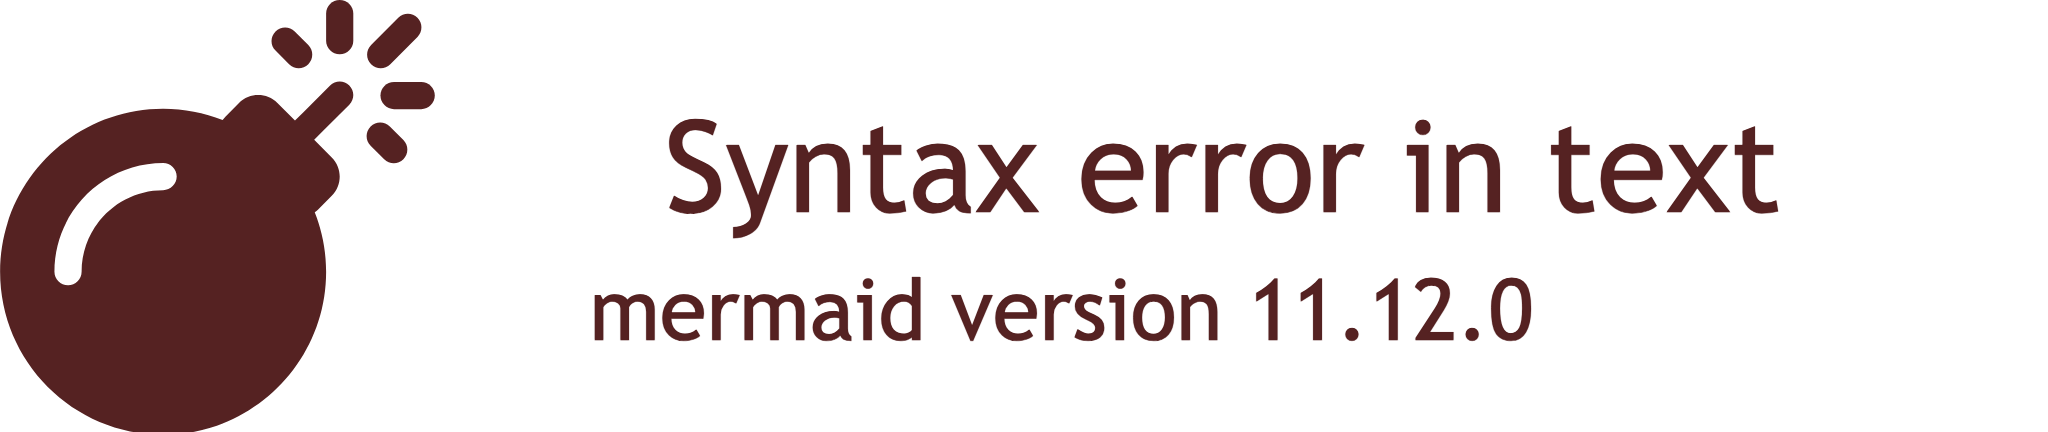